<a href="https://colab.research.google.com/github/Mounia-Agronomist-Datascientist/AT-T_project/blob/main/1_AT_T_project_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **________ AT&T project ________** #

*The goal of this project is to build a spam detector, that can automatically flag spams as they come based solely on the sms' content.*

## **I. EDA**

###  **0. Configuration & Drive setup**

The following code performs setup actions that are necessary for every session:



* **drive.mount():** Connects Drive to the temporary Colab machine.
* **os.chdir(PROJECT_PATH)**: Moves Python session into the project folder.
* **sys.path.append('src'):** Allows us to import our .py files (for instance : custumed functions).

This cell must be run in the first cell of every notebook, every time a session is started.

In [5]:
#  --------------  CODE TO MOUNT DRIVE AND SET WORKING DIRECTORY   --------------

from google.colab import drive
import os

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define your project path
PROJECT_PATH = '/content/drive/MyDrive/Colab_Projects/AT-T_project'

# 3. Change current directory to the project path
os.chdir(PROJECT_PATH)

# 4. Add the 'src' directory to Python's system path

import sys
if 'src' not in sys.path:
    sys.path.append('src')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


###  **1. Libraries import**

In [60]:
import io
import os
import re
import shutil
import tarfile
import string

import tiktoken
import requests
import numpy as np
import pandas as pd

# ================ STATISTICS ===============
from scipy.stats import ttest_ind

# =============== VISUALIZATION =============
import matplotlib.pyplot as plt
import seaborn as sns

# ==================== NLP ==================
from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer

# ==================== ML ==================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, f1_score,precision_score, recall_score, confusion_matrix
from scipy.sparse import hstack
import xgboost as xgb

# =============== DEEP LEARNING =============
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device.")

Using cpu device.


### **2. Data import & general information on the dataset**

In [7]:
raw_df=pd.read_csv('./DATA/DATA_raw/spam.csv',encoding='latin-1')

# The file contains some specific characters that are not valid under the
# utf-8 encoding scheme so we select the 'latin-1 encoding that covers all 256 byte values.

raw_df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [8]:
raw_df.shape

(5572, 5)

In [9]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [10]:
raw_df.describe(include='all')

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


This dataset contains 5 columns, but only the first 2 will be used for this analysis. Indeed, the last 3 columns contain too many NaN values to have significant meaning.

### **3. Data cleaning**

Dropping useless columns and renaming the other ones :

In [11]:
df = raw_df.rename(columns={'v1': 'label', 'v2': 'message'})
df = df[['label', 'message']]

Check for duplicated rows:

In [12]:
duplicates = df.duplicated().sum()
print(f"There are : {duplicates} duplicated rows, this represents {round((100*duplicates/df.shape[0]),2)} % of the dataset.")

There are : 403 duplicated rows, this represents 7.23 % of the dataset.


Approximately 7.2% of the dataset is identified as duplicated. We are going to deeper investigate these duplicates :


In [13]:
# We select and order the duplicated rows:

df[df.duplicated(keep=False)].sort_values(by=["label", "message"])

,label,message
1372,ham,1) Go to write msg 2) Put on Dictionary mode 3...
2162,ham,1) Go to write msg 2) Put on Dictionary mode 3...
2343,ham,1) Go to write msg 2) Put on Dictionary mode 3...
1469,ham,7 wonders in My WORLD 7th You 6th Ur style 5th...
1778,ham,7 wonders in My WORLD 7th You 6th Ur style 5th...
...,...,...
5035,spam,You won't believe it but it's true. It's Incre...
2832,spam,You've won tkts to the EURO2004 CUP FINAL or å...
3003,spam,You've won tkts to the EURO2004 CUP FINAL or å...
95,spam,Your free ringtone is waiting to be collected....


In [14]:
# We check that every duplicate has only one label (not both ham and spam)

df.groupby("message")["label"].nunique().value_counts()

,count
label,
1,5169


The results confirmed that there are no inconsistencies (i.e., no message labeled both as spam and ham).

In the context of natural language processing, keeping duplicated messages may introduce bias by over-representing certain texts, which can lead to overfitting and reduced generalization performance.

Therefore, we decided to remove duplicates based on the message content, keeping only unique messages in the dataset. This approach helps improve model robustness and ensures a more balanced representation of the textual data.

In [15]:
df = df.drop_duplicates(subset=["message"])

In [16]:
print(f"{len(raw_df)-len(df)} rows have been dropped.")

403 rows have been dropped.


In [17]:
print(f"The cleaned dataset has : {df.shape[0]} rows and {df.shape[1]} columns.")

The cleaned dataset has : 5169 rows and 2 columns.


### **4. Class Distribution**

***1. Class distribution of the target***

In [18]:
distribution = round(100 * df['label'].value_counts(normalize=True),2)
distribution

,proportion
label,
ham,87.37
spam,12.63


We can notice that our target variable (spam or non-spam) is **imbalanced.** It means that for evaluating our models we are going to focus more on Precision, Recall, and F1-score rather than just Accuracy. Moreover, we will potentially require sampling techniques (like oversampling (SMOTE)) or undersampling).

***2. Label Encoding***

For Machine Learning, we need to convert labels into numbers:

In [19]:
# 0 -> represents the non spam class 'ham'
# 1 -> represents the spam class  `spam`

In [20]:
df['encoded_label'] = df['label'].map({'ham': 0, 'spam': 1})

In [21]:
df.head(10)

,label,message,encoded_label
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0
5,spam,FreeMsg Hey there darling it's been 3 week's n...,1
6,ham,Even my brother is not like to speak with me. ...,0
7,ham,As per your request 'Melle Melle (Oru Minnamin...,0
8,spam,WINNER!! As a valued network customer you have...,1
9,spam,Had your mobile 11 months or more? U R entitle...,1


### **5. Message length analysis**

We are now going to check if the spam messages have specific patters. First, we will check the lenght of messages. Are spams shorter? Longer? Is there a significant difference? We can check two kind of lenghts : the number of total characters in the message and the number of words.

In [22]:
# Number of characters in the messages :
df['nb_chars'] = df['message'].apply(len)

# Number of words in the messages
df['nb_words'] = df['message'].apply(lambda x: len(x.split()))

In [23]:
df.head(5)

,label,message,encoded_label,nb_chars,nb_words
0,ham,"Go until jurong point, crazy.. Available only ...",0,111,20
1,ham,Ok lar... Joking wif u oni...,0,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,155,28
3,ham,U dun say so early hor... U c already then say...,0,49,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,61,13


In [24]:
ham_df = df[df['label'] == 'ham'].copy()
spam_df = df[df['label'] == 'spam'].copy()

In [25]:
ham_df.describe(exclude = object)

,encoded_label,nb_chars,nb_words
count,4516.0,4516.000000,4516.000000
mean,0.0,70.459256,14.134632
std,0.0,56.358207,11.116240
min,0.0,2.000000,1.000000
25%,0.0,34.000000,7.000000
50%,0.0,52.000000,11.000000
75%,0.0,90.000000,18.000000
max,0.0,910.000000,171.000000


In [26]:
spam_df.describe(exclude = object)

,encoded_label,nb_chars,nb_words
count,653.0,653.000000,653.000000
mean,1.0,137.891271,23.681470
std,0.0,30.137753,5.967672
min,1.0,13.000000,2.000000
25%,1.0,132.000000,22.000000
50%,1.0,149.000000,25.000000
75%,1.0,157.000000,28.000000
max,1.0,224.000000,35.000000


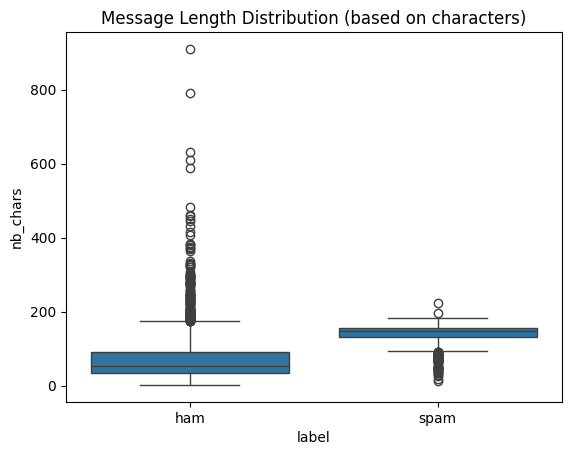

In [27]:
sns.boxplot(x="label", y="nb_chars", data=df)

plt.title("Message Length Distribution (based on characters)")
plt.show()

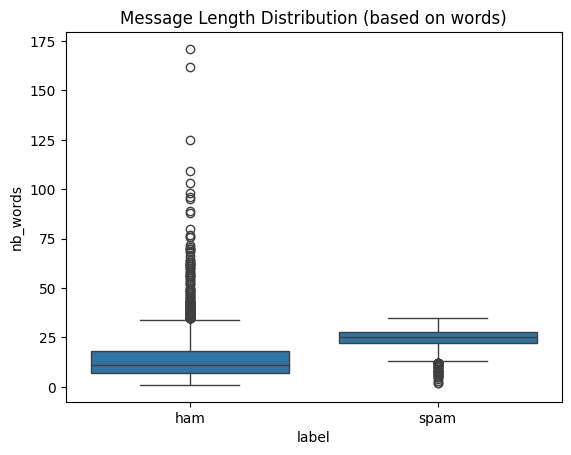

In [28]:
sns.boxplot(x="label", y="nb_words", data=df)

plt.title("Message Length Distribution (based on words)")
plt.show()

The boxplots suggest a difference in the lengths of spam messages, which appear to be longer. We need to validate this difference using a statistic test. First we can chek if the data are normally distributed:

In [29]:
from scipy.stats import shapiro

shapiro(df["nb_chars"])


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5169.
  res = hypotest_fun_out(*samples, **kwds)


ShapiroResult(statistic=np.float64(0.8093064896464311), pvalue=np.float64(2.2735091279079024e-61))

Given the large sample size and the Shapiro test result (p-value < 0.05), the data does not follow a normal distribution. Therefore, I used a non-parametric Mann-Whitney test.

In [30]:
from scipy.stats import mannwhitneyu

stat, p_value = mannwhitneyu(ham_df["nb_chars"],
                            spam_df["nb_chars"])

print(p_value)

4.6033274103229373e-212


In [31]:
stat, p_value = mannwhitneyu(ham_df["nb_words"],
                            spam_df["nb_words"])
print(p_value)

6.409562529593963e-150


In both cases the p-value < 0.05 so the difference is meaningful. We can say that spam messages have generally more words and characters than ham messages.
The ham messages have on average:

*   70 characters,
*   14 words,
so they are relatively short.

Whereas spam messages have on average:

*  138 characters
*  23 words.

Lenght is a useful feature for our analysis.



### **6. Word frequency analysis**

We have seen a significant difference between spams and hams in terms of lenght of the messages, what about the words themselves? Is there a significant difference of vocabulary used? In order to lead such an analysis, we need to apply a basic preprocessing on the text.

***1. Basic preprocess***

In [32]:
# We put the words in lower mode and remove all the punctuation

df['cleaned_message'] = df['message'].apply(lambda x: ''.join(c for c in x.lower() if c not in string.punctuation))

In [33]:
df.head()

,label,message,encoded_label,nb_chars,nb_words,cleaned_message
0,ham,"Go until jurong point, crazy.. Available only ...",0,111,20,go until jurong point crazy available only in ...
1,ham,Ok lar... Joking wif u oni...,0,29,6,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,155,28,free entry in 2 a wkly comp to win fa cup fina...
3,ham,U dun say so early hor... U c already then say...,0,49,11,u dun say so early hor u c already then say
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,61,13,nah i dont think he goes to usf he lives aroun...


***2. Most frequent words***

In [34]:
# We create a function for counting the words

def top_words(texts, top_n=20):
    """
    Counts the most frequent words in a series of texts.

    Arguments:
        texts (iterable): list or Series of texts
        top_n (int): number of top words to display
    """
    all_words = ' '.join(texts).split()
    counts = Counter(all_words)
    for word, count in counts.most_common(top_n):
        print(f"- {word} : {count} occurrences")


Top 15 words for the whole dataset :

In [35]:
top_words(df['cleaned_message'],15)

- i : 2116 occurrences
- to : 2068 occurrences
- you : 2032 occurrences
- a : 1288 occurrences
- the : 1228 occurrences
- u : 1001 occurrences
- and : 922 occurrences
- in : 813 occurrences
- is : 789 occurrences
- me : 738 occurrences
- my : 678 occurrences
- for : 660 occurrences
- your : 619 occurrences
- it : 571 occurrences
- of : 558 occurrences


Top 15 words for the ham messages:

In [36]:
top_words(df[df['label'] == 'ham']['cleaned_message'],15)

- i : 2075 occurrences
- you : 1773 occurrences
- to : 1474 occurrences
- the : 1047 occurrences
- a : 957 occurrences
- u : 878 occurrences
- and : 818 occurrences
- in : 751 occurrences
- me : 712 occurrences
- my : 668 occurrences
- is : 645 occurrences
- it : 546 occurrences
- of : 477 occurrences
- for : 476 occurrences
- that : 472 occurrences


Top 15 words for the spam messages:

In [37]:
top_words(df[df['label'] == 'spam']['cleaned_message'],15)

- to : 594 occurrences
- a : 331 occurrences
- call : 303 occurrences
- you : 259 occurrences
- your : 241 occurrences
- free : 188 occurrences
- for : 184 occurrences
- the : 181 occurrences
- or : 157 occurrences
- now : 156 occurrences
- 2 : 155 occurrences
- is : 144 occurrences
- txt : 126 occurrences
- u : 123 occurrences
- on : 121 occurrences


We can see that the most frequent words in the whole dataset are quite similar to those in ham messages. But it could be explained by the hight proportion of ham messages in the dataset. However, we notice that the most common word is "I", whereas this pronoun is not in the top 15 words for spam messages. Moreover, "free" is a word very present in spams but not in ham messages. Let's visualize the differences with wordclouds.

In [38]:
def wordcloud(text, ax, title, colormap):
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap=colormap,
        max_words=100
    ).generate(text)

    ax.imshow(wordcloud, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=16, fontweight='bold')

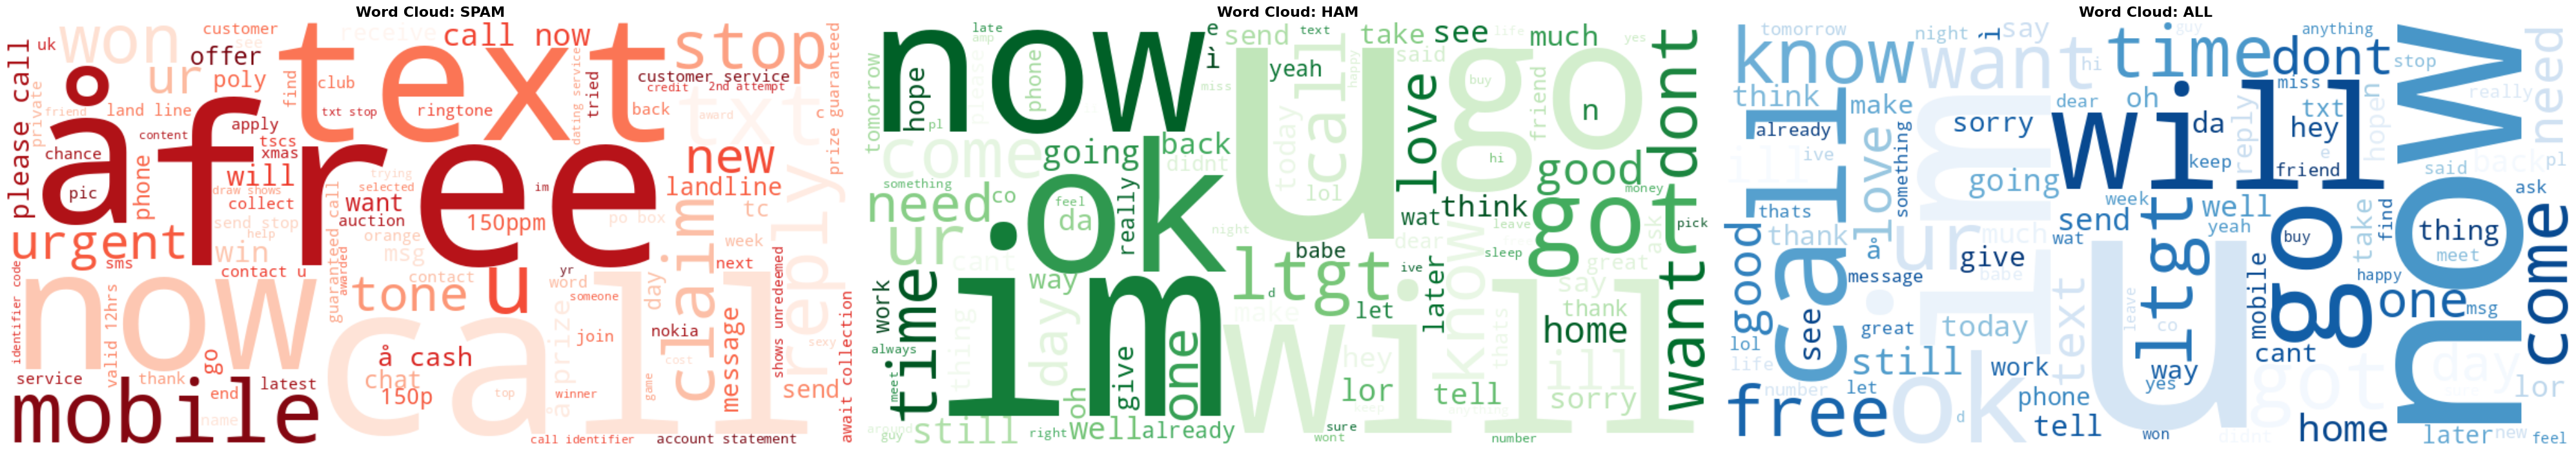

In [39]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(40, 15))

# SPAM
spam_text = ' '.join(df[df['label'] == 'spam']['cleaned_message'])
wordcloud(spam_text, axes[0], 'Word Cloud: SPAM', 'Reds')

# HAM
ham_text = ' '.join(df[df['label'] == 'ham']['cleaned_message'])
wordcloud(ham_text, axes[1], 'Word Cloud: HAM', 'Greens')

# ALL DATA
all_text = ' '.join(df['cleaned_message'])
wordcloud(all_text, axes[2], 'Word Cloud: ALL', 'Blues')

plt.tight_layout()
plt.show()

We can identify words that are frequently present in spams but rare or not present in the ham messages and ignore common words. To do so, we are using TD-IDF (TF-IDF measures how important a word is in a document relative to a corpus by combining its frequency in the document with its rarity across all documents). Here each message from the dataset represents a document.

In [40]:
# Global TF-IDF
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

X = vectorizer.fit_transform(df['cleaned_message'])
feature_names = vectorizer.get_feature_names_out()

In [41]:
# Separate Ham and Spam
mask_spam = (df['label'] == 'spam').to_numpy()
mask_ham = (df['label'] == 'ham').to_numpy()

X_spam = X[mask_spam]
X_ham = X[mask_ham]

In [42]:
# Mean TF-IDF per class
mean_spam = np.asarray(X_spam.mean(axis=0)).flatten()
mean_ham = np.asarray(X_ham.mean(axis=0)).flatten()

In [43]:
# Difference
diff = mean_spam - mean_ham
print(diff)

[ 0.00090332  0.00057116  0.00041019 ...  0.0005083   0.00047676
 -0.00064343]


For each element of the vector:


*   If the result is positif : the word is typical from Spam
*   If the result is negative : the word is typical of Ham



We need to filter the rare word to avoid noise in our result

In [44]:
word_counts = np.asarray(X.sum(axis=0)).flatten()

# We keep only non-rare words
mask = word_counts > 10

Top spam typical words:

In [45]:
top_spam_idx = diff.argsort()[::-1]

top_spam_words = [
    feature_names[i]
    for i in top_spam_idx
    if mask[i]
][:10]


print("Top SPAM words:")
for word in top_spam_words:
  print(f"   - {word}")

Top SPAM words:
   - free
   - txt
   - mobile
   - claim
   - prize
   - stop
   - reply
   - text
   - urgent
   - won


Top ham typical words

In [46]:
top_ham_idx = diff.argsort()

top_ham_words = [
    feature_names[i]
    for i in top_ham_idx
    if mask[i]
][:10]

print("Top HAM words:")
for word in top_ham_words:
  print(f"   - {word}")

Top HAM words:
   - im
   - ok
   - ltgt
   - come
   - ill
   - got
   - lor
   - home
   - going
   - like


By computing the difference of mean TF-IDF scores between spam and ham and filtering out low-frequency words, we can identify discriminative terms for each class:

| SPAM | HAM |
|---|---|
|free|im|
|txt|ok|
|mobile|ltgt|
|claim|come|
|prize|ill|
|stop|got|
|reply|lor|
|text|home|
|urgent|going|
|won|like|


### **7. Special characters analysis**

Generally, spam messages are crafted to be more eye-catching, so they might use more punctuation, emojis, or capital letters. Let's analyze specific characters to check if we see differences between spam and ham messages. For that, we create new columns in our dataframe.

In [47]:
# Capital letters
df['nb_capitals'] = df['message'].str.count(r'[A-Z]')
df['percent_capitals'] = df['nb_capitals'] / df['message'].str.len() * 100

# Punctuation
df['nb_exclamations'] = df['message'].str.count('!')
df['nb_punctuation'] = df['message'].str.count(r'[.,!?;:()\-"\']')

# Digits and phone numbers
df['nb_digits'] = df['message'].str.count(r'\d')
df['has_phone_number'] = df['message'].str.contains(r'\d{5,}').astype(int)

# Money symbols
df['has_money_symbol'] = df['message'].str.contains(r'[£$€]').astype(int)

# Emogis
df['nb_emojis'] = df['message'].str.count(
    r'[\U0001F1E0-\U0001F1FF'  # flags
    r'\U0001F300-\U0001F5FF'  # symbols
    r'\U0001F600-\U0001F64F'  # smileys
    r'\U0001F680-\U0001F6FF'  # transport
    r'\U0001F700-\U0001F77F'  # alchemical symbols
    r'\U0001F900-\U0001F9FF'  # supplemental symbols
    r'\U0001FA00-\U0001FAFF'  # recent emojis
    r']'
)

Now that we have all the necessary columns to evaluate the special characters, we can lead statistical analysis and compaire Spams and Hams

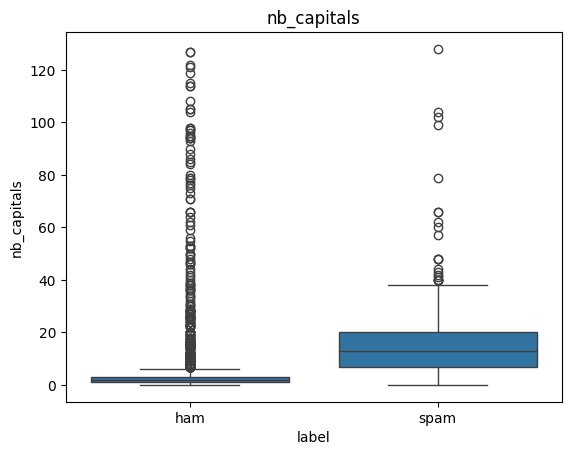

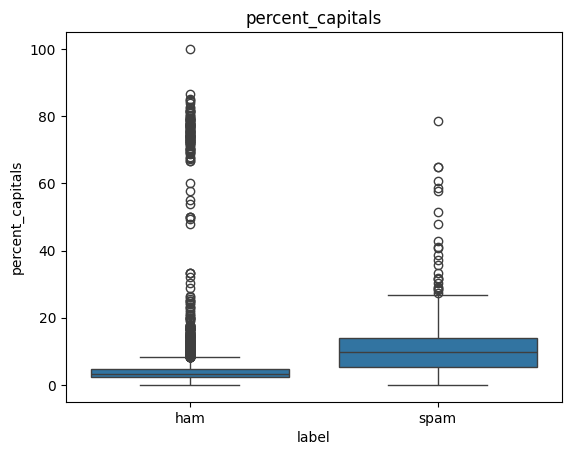

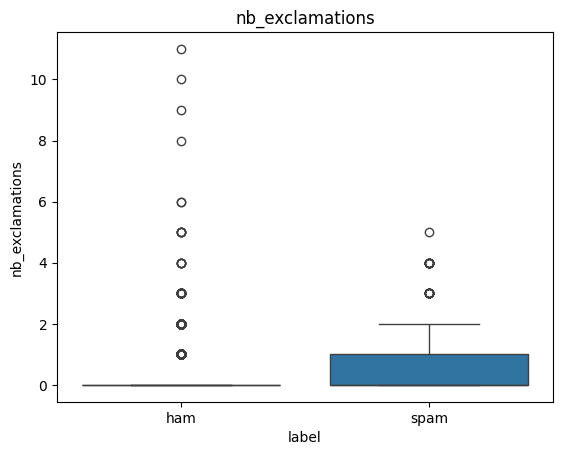

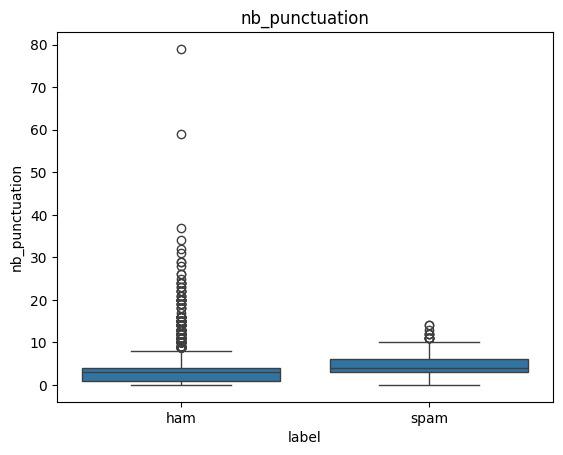

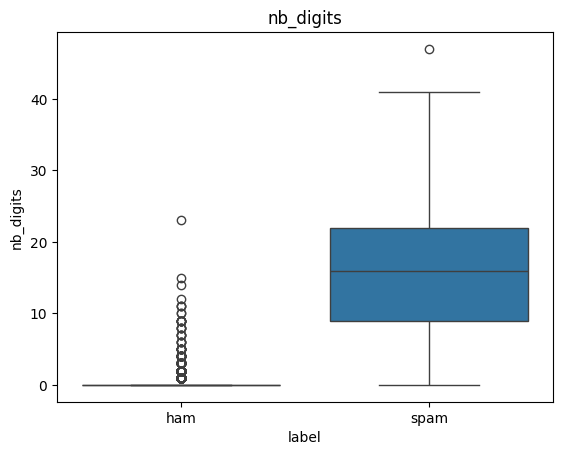

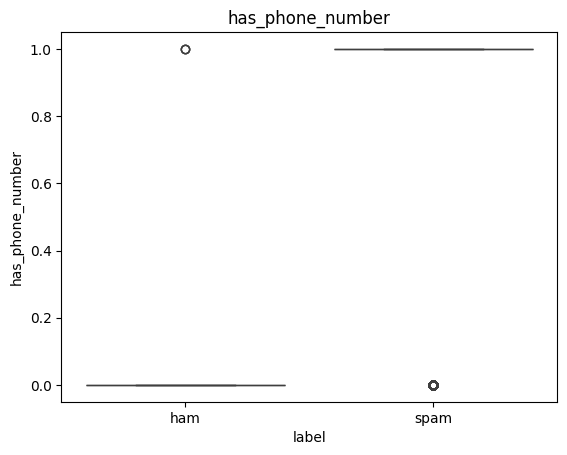

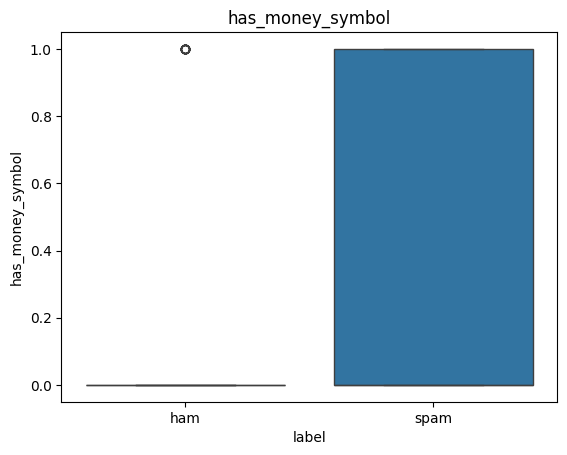

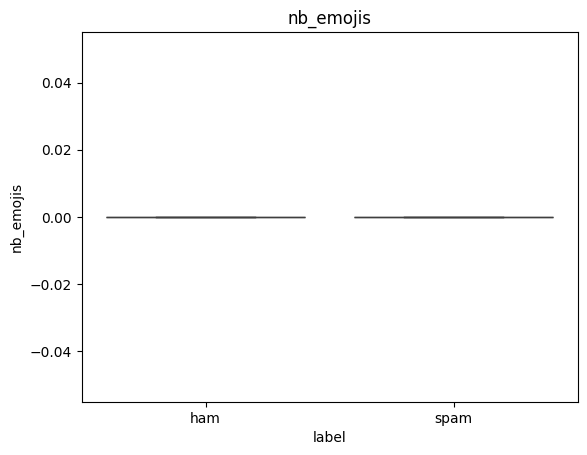

In [48]:
features = [
    'nb_capitals', 'percent_capitals',
    'nb_exclamations', 'nb_punctuation',
    'nb_digits', 'has_phone_number',
    'has_money_symbol', 'nb_emojis'
]

for col in features:
    sns.boxplot(x='label', y=col, data=df)
    plt.title(col)
    plt.show()

In [49]:
# Comparative table

comparison = df.groupby('label')[['nb_chars', 'nb_words', 'nb_capitals',
                                   'percent_capitals', 'nb_exclamations',
                                   'nb_digits', 'has_phone_number',
                                   'has_money_symbol']].mean()
print(comparison.round(2))

       nb_chars  nb_words  nb_capitals  percent_capitals  nb_exclamations  \
label                                                                       
ham       70.46     14.13         3.83              5.67             0.17   
spam     137.89     23.68        15.23             10.99             0.69   

       nb_digits  has_phone_number  has_money_symbol  
label                                                 
ham         0.29              0.00              0.00  
spam       15.45              0.77              0.33  


In [50]:
for col in features:
    spam = df[df['label'] == 'spam'][col]
    ham = df[df['label'] == 'ham'][col]

    stat, p = ttest_ind(spam, ham, equal_var=False)
    print(f"{col}: p-value = {p}")

nb_capitals: p-value = 4.8699178433799e-84
percent_capitals: p-value = 1.6957840760497658e-40
nb_exclamations: p-value = 1.145326272144869e-39
nb_punctuation: p-value = 1.1178847314828227e-14
nb_digits: p-value = 1.4278504420374323e-194
has_phone_number: p-value = 1.7482777349433123e-207
has_money_symbol: p-value = 5.526978951672833e-58
nb_emojis: p-value = nan


All p-values are below 0.05, meaning that the differences between ham and spam are statistically significant. We can confirm our hypothesis that spams have more capital letteres, punctuation characters, phones numbers and money symbols in order to catch the attention of people.

### **8. EDA Conclusion**

This exploratory analysis revealed critical insights for our spam detection model. The dataset is **highly imbalanced** (86.6% ham, 13.4% spam), requiring the use of class weighting or SMOTE and evaluation metrics focused on F1-score rather than accuracy.

Spam messages are **significantly longer** (138 vs 70 characters on average, p<0.05) and exhibit distinct linguistic patterns with discriminative vocabulary (e.g., "free", "claim", "prize" for spam vs "im", "ok", "got" for ham) identified through TF-IDF analysis.

Spam messages also contain **significantly more capital letters, exclamation marks, digits, and money symbols** (all p<0.05), which can be engineered as additional features.

These findings will guide our preprocessing strategy (tokenization with ~5,000-10,000 vocabulary size, padding to ~150-200 tokens) and model architecture (text embeddings combined with numerical features for length and special characters, using LSTM/GRU layers for sequence modeling). The dataset is now cleaned, duplicate-free, and ready for the modeling phase.

In [51]:
# Save the cleaned dataset with all engineered features
df.to_csv('./DATA/DATA_processed/spam_cleaned_features.csv', index=False)

## **II. PREPROCESSING AND MODELING**

### **0. Import cleaned dataset**

In [52]:
df = pd.read_csv('./DATA/DATA_processed/spam_cleaned_features.csv')

### **1. Preprocessing for basic models**

The previous exploratory data analysis revealed that capital words and punctuation (like "!" and "?") are more frequent in spam messages.

The problem is that standard preprocessing (lowercase + remove punctuation) loses this information.

To face this issue, we will create a custom tokenization by creating features that capture these patterns while still tokenizing properly.

To do so, we will combine :
1. The numeric features about capitals/punctuation that have already been extracted during the EDA phase
2. The normalized text for TF-IDF

First we need to standardize the numerical features because they have different scales (but only the train set so before, we will apply the train/test split).

In [53]:
# Numerical features related to punctuation, numbers and capital letters (from EDA)
numeric_feature_cols = [
    'nb_chars',
    'nb_words',
    'nb_capitals',
    'percent_capitals',
    'nb_exclamations',
    'nb_punctuation',
    'nb_digits',
    'has_phone_number',
    'has_money_symbol',
    'nb_emojis'
]

In [54]:
# TRAIN/VAL/TEST SPLIT

# --- Train/val/test sets'sizes
train_size = 0.7
val_size = 0.15
test_size = 0.15

# --- First split
train_df, temp_df = train_test_split(
        df,
        test_size= 1 - train_size,
        stratify=df['label'],
        random_state=42
    )

# --- Second split
val_df, test_df = train_test_split(
        temp_df,
        test_size= test_size,
        stratify=temp_df['label'],
        random_state=42
    )

# --- Extract labels
y_train = train_df['label']
y_val = val_df['label']
y_test = test_df['label']

In [55]:
# STANDARDIZATION of numeric features

# --- Extract numeric features
X_train_numeric = train_df[numeric_feature_cols].select_dtypes(include = [int, float])
X_val_numeric = val_df[numeric_feature_cols].select_dtypes(include = [int, float])
X_test_numeric = test_df[numeric_feature_cols].select_dtypes(include = [int, float])

# --- Standardize (fit on train only, transform all sets)
scaler = StandardScaler()
X_train_numeric_scaled = scaler.fit_transform(X_train_numeric)
X_val_numeric_scaled = scaler.transform(X_val_numeric)
X_test_numeric_scaled = scaler.transform(X_test_numeric)

During EDA, we fit a TF-IDF vectorizer on the entire dataset to analyze global vocabulary patterns and identify discriminative words. However, for modeling, we created a new vectorizer fit only on the training set to avoid data leakage.

In [56]:
text_col = 'cleaned_message'

# TF-IDF vectorizer
vectorizer_model = TfidfVectorizer(
    max_features=3000,       # Top 3000 words
    ngram_range=(1, 2),      # Unigrams + bigrams
    min_df=2,                # Word must appear in at least 2 docs
    max_df=0.95,             # Ignore words in >95% of docs
    sublinear_tf=True,       # Use log(tf) instead of raw tf
)

# Fit on train, transform all sets
X_train_tfidf = vectorizer_model.fit_transform(train_df[text_col])
X_val_tfidf = vectorizer_model.transform(val_df[text_col])
X_test_tfidf = vectorizer_model.transform(test_df[text_col])

Now we can combine TF_IDF and the numeric features.

In [57]:
# hstack combines sparse (TF-IDF) and dense (numeric) matrices
X_train_combined = hstack([X_train_tfidf, X_train_numeric_scaled])
X_val_combined = hstack([X_val_tfidf, X_val_numeric_scaled])
X_test_combined = hstack([X_test_tfidf, X_test_numeric_scaled])

### **2. Machine learning models**

Given the class imbalance in our dataset, accuracy is not an appropriate metric.
Instead, we focus on:

*   F1-Score as our primary metric (harmonic mean of precision and recall),
*   Precision to minimize false positives (avoid blocking legitimate messages)
*   Recall to maximize spam detection (catch as much spam as possible),
*   Confusion Matrix to understand the types of errors our model makes.

**1. Logistic regression (baseline)**

In [66]:
# 1. Train model
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train_combined, y_train)

# 2. Evaluate
y_pred = model_lr.predict(X_test_combined)

# 3. Metrics
f1_lr = f1_score(y_test, y_pred, pos_label="spam")
precision_lr = precision_score(y_test, y_pred,pos_label="spam")
recall_lr = recall_score(y_test, y_pred,pos_label="spam")
cm_lr = confusion_matrix(y_test, y_pred)

print(f"F1 Score : {f1_lr:.3f}")
print(f"Precision Score : {precision_lr:.3f}")
print(f"Recall score: {recall_lr:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))


F1 Score : 0.964
Precision Score : 1.000
Recall score: 0.931

Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      1.00      1.00       204
        Spam       1.00      0.93      0.96        29

    accuracy                           0.99       233
   macro avg       1.00      0.97      0.98       233
weighted avg       0.99      0.99      0.99       233



The logistic regression, which is our baseline model, already gives us a high F1 score (96,4%). We are now going to improve this result with an XGboost model.

**2. XGboost (improvement)**

In [70]:
y_train_xg = train_df['encoded_label']
y_val_xg = val_df['encoded_label']
y_test_xg = test_df['encoded_label']


# 1. Train model
model_xg = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)
model_xg.fit(X_train_combined, y_train_xg)
model_xg.fit(X_train_combined, y_train_xg)

# 2. Evaluate
y_pred_xg = model_xg.predict(X_test_combined)

# 3. Metrics
f1_xg = f1_score(y_test_xg, y_pred_xg)
precision_xg = precision_score(y_test_xg, y_pred_xg)
recall_xg = recall_score(y_test_xg, y_pred_xg)
cm_xg = confusion_matrix(y_test_xg, y_pred_xg)

print(f"F1 Score : {f1_xg:.3f}")
print(f"Precision Score : {precision_xg:.3f}")
print(f"Recall score: {recall_xg:.3f}")
print("\nClassification Report:")
print(classification_report(y_test_xg, y_pred_xg, target_names=['Ham', 'Spam']))


F1 Score : 0.966
Precision Score : 0.966
Recall score: 0.966

Classification Report:
              precision    recall  f1-score   support

         Ham       1.00      1.00      1.00       204
        Spam       0.97      0.97      0.97        29

    accuracy                           0.99       233
   macro avg       0.98      0.98      0.98       233
weighted avg       0.99      0.99      0.99       233



The XGboost model allows us to improve a bit the F1_score, mainly by increasing the Recall, even if the Precision dicreased a bit.

### **3. Preprocessing for deep learning models**

We already have good results with the XGboost model, but we can try to improve them with deep learning models like LSTM, but in this case, the preprocessing is a bit different than with TF-IDF. Here, we need to create a vocabulary, add padding , etc.

## **IV. EVALUATION**